In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from itertools import combinations
from scipy.stats import chisquare, entropy, ks_2samp, wasserstein_distance
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import umap.umap_ as umap


/Users/horyu72/Desktop/projekt/Bierprojekt/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
real_path = "../../data/data_for_CTGAN/CTGAN_basedata.csv"
syn_path = "../../data/synthetic_result_data/536_synthetic_train_data.csv"
df_real = pd.read_csv(real_path)
df_syn = pd.read_csv(syn_path)

# Statistical Analysis

### Distribution of each features

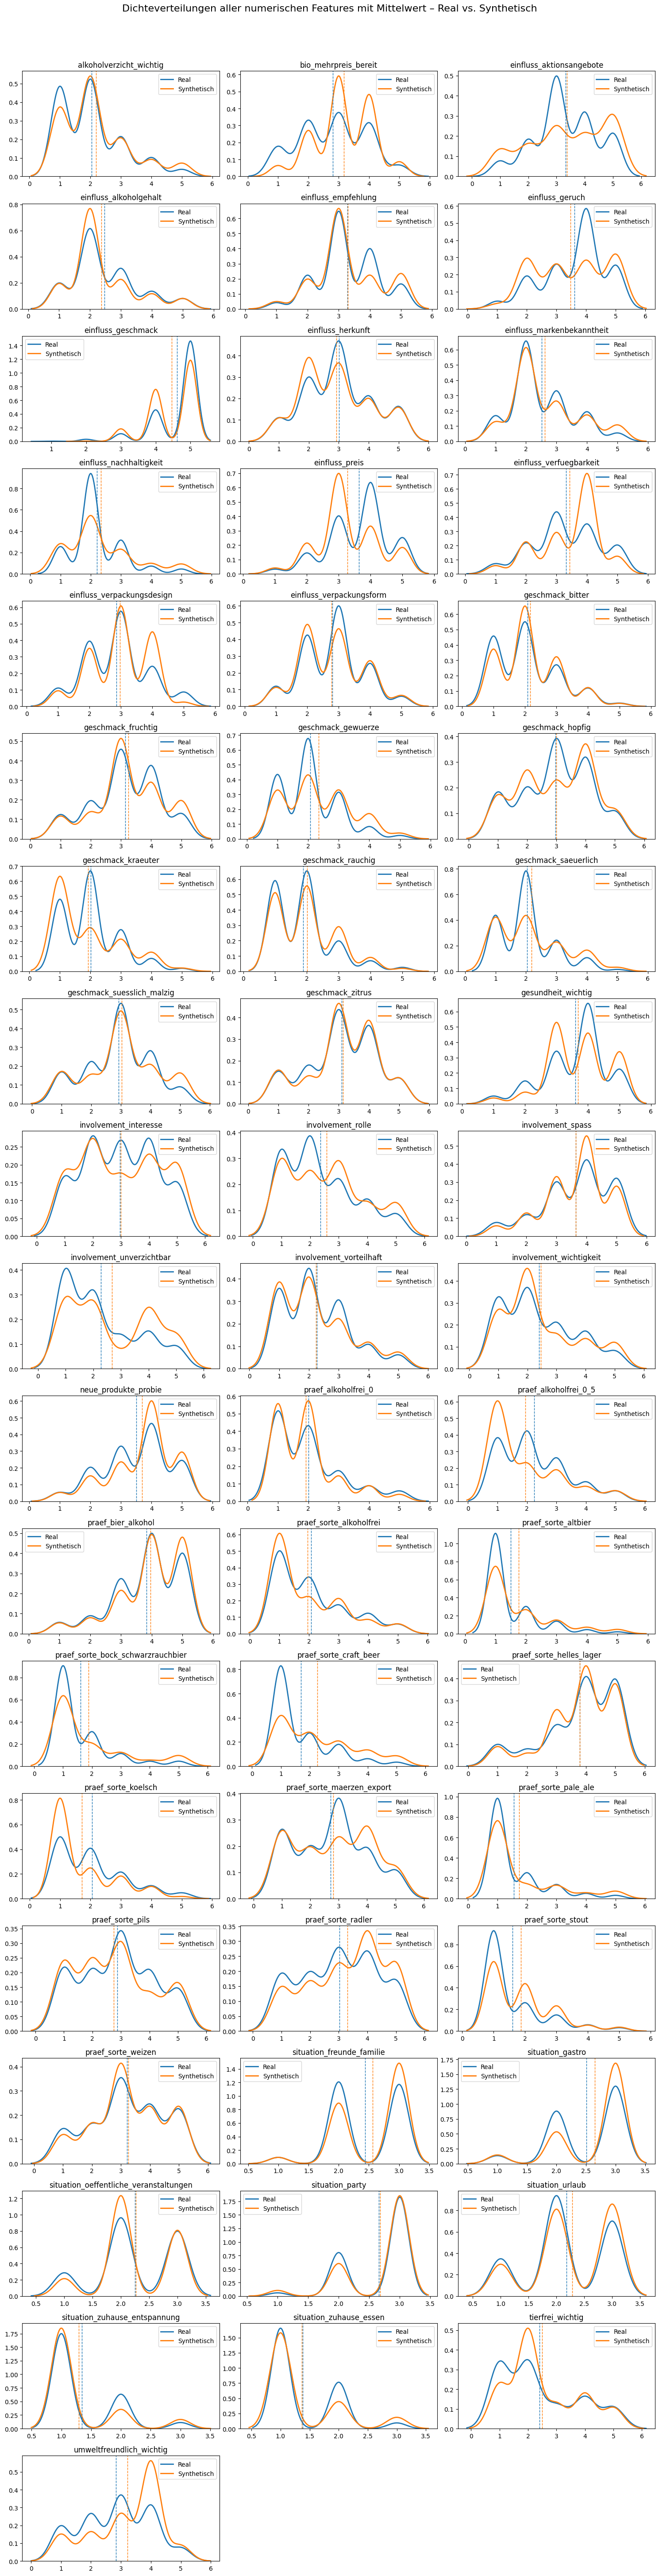

In [3]:
df_real_num = df_real.select_dtypes(include='number')
df_syn_num = df_syn.select_dtypes(include='number')

common_cols = list(set(df_real_num.columns) & set(df_syn_num.columns))
df_real_num = df_real_num[common_cols]
df_syn_num = df_syn_num[common_cols]

# Plot-Einstellungen
n_cols = 3
n_rows = (len(common_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 3))


for i, col in enumerate(sorted(common_cols)):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # KDEs
    sns.kdeplot(df_real_num[col], label="Real", color="tab:blue", linewidth=2)
    sns.kdeplot(df_syn_num[col], label="Synthetisch", color="tab:orange", linewidth=2)
    
    # Mittelwerte
    plt.axvline(df_real_num[col].mean(), color="tab:blue", linestyle="--", linewidth=1)
    plt.axvline(df_syn_num[col].mean(), color="tab:orange", linestyle="--", linewidth=1)
    
    plt.title(col)
    plt.xlabel("")
    plt.ylabel("")
    plt.legend()

plt.tight_layout()
plt.suptitle("Dichteverteilungen aller numerischen Features mit Mittelwert – Real vs. Synthetisch", y=1.02, fontsize=16)
plt.show()


### Feature - Situation

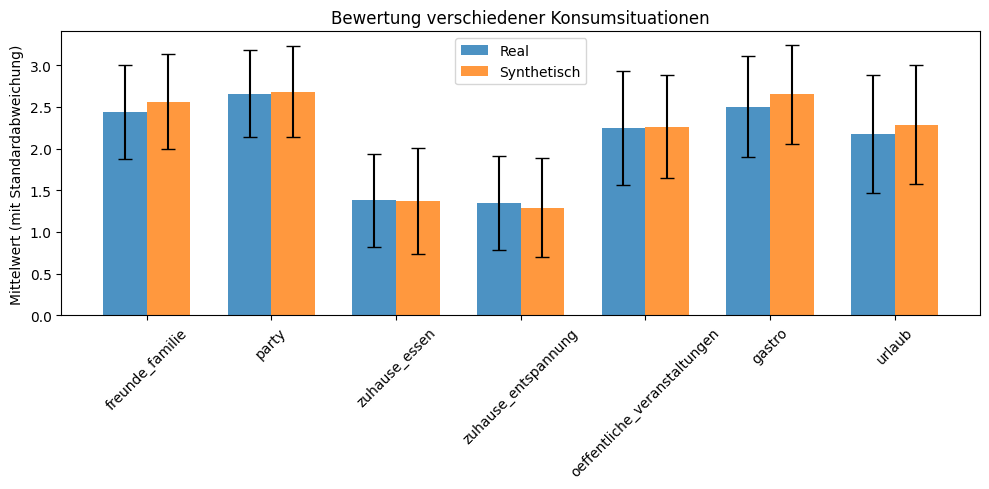

In [4]:
situation_features = [
    "situation_freunde_familie",
    "situation_party",
    "situation_zuhause_essen",
    "situation_zuhause_entspannung",
    "situation_oeffentliche_veranstaltungen",
    "situation_gastro",
    "situation_urlaub"
]

# Numerisch konvertieren, falls noch nicht
df_real[situation_features] = df_real[situation_features].apply(pd.to_numeric, errors='coerce')
df_syn[situation_features] = df_syn[situation_features].apply(pd.to_numeric, errors='coerce')

# Mittelwerte & Standardabweichungen berechnen
mean_real = df_real[situation_features].mean()
std_real = df_real[situation_features].std()
mean_syn = df_syn[situation_features].mean()
std_syn = df_syn[situation_features].std()

# Plot vorbereiten
x = range(len(situation_features))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetisch', alpha=0.8)

plt.xticks(x, [s.replace("situation_", "") for s in situation_features], rotation=45)
plt.ylabel("Mittelwert (mit Standardabweichung)")
plt.title("Bewertung verschiedener Konsumsituationen")
plt.legend()
plt.tight_layout()
plt.show()

### Feature - Involvement

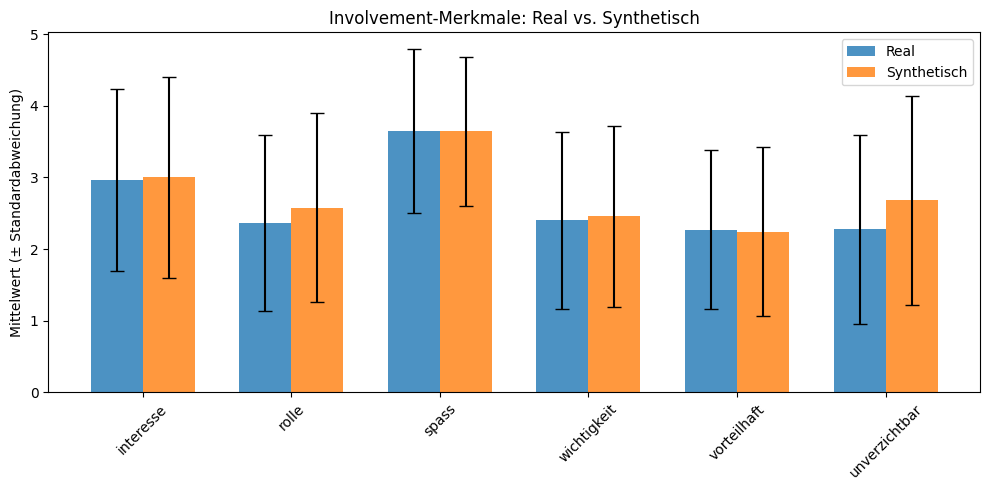

In [5]:
# Liste der 'involvement'-Features
involvement_features = [
    "involvement_interesse",
    "involvement_rolle",
    "involvement_spass",
    "involvement_wichtigkeit",
    "involvement_vorteilhaft",
    "involvement_unverzichtbar"
]

# Konvertiere zu numerisch (falls nötig)
df_real[involvement_features] = df_real[involvement_features].apply(pd.to_numeric, errors='coerce')
df_syn[involvement_features] = df_syn[involvement_features].apply(pd.to_numeric, errors='coerce')

# Mittelwerte und Standardabweichungen
mean_real = df_real[involvement_features].mean()
std_real = df_real[involvement_features].std()
mean_syn = df_syn[involvement_features].mean()
std_syn = df_syn[involvement_features].std()

# Plot erstellen
x = range(len(involvement_features))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetisch', alpha=0.8)

plt.xticks(x, [s.replace("involvement_", "") for s in involvement_features], rotation=45)
plt.ylabel("Mittelwert (± Standardabweichung)")
plt.title("Involvement-Merkmale: Real vs. Synthetisch")
plt.legend()
plt.tight_layout()
plt.show()


### Feature - Influences

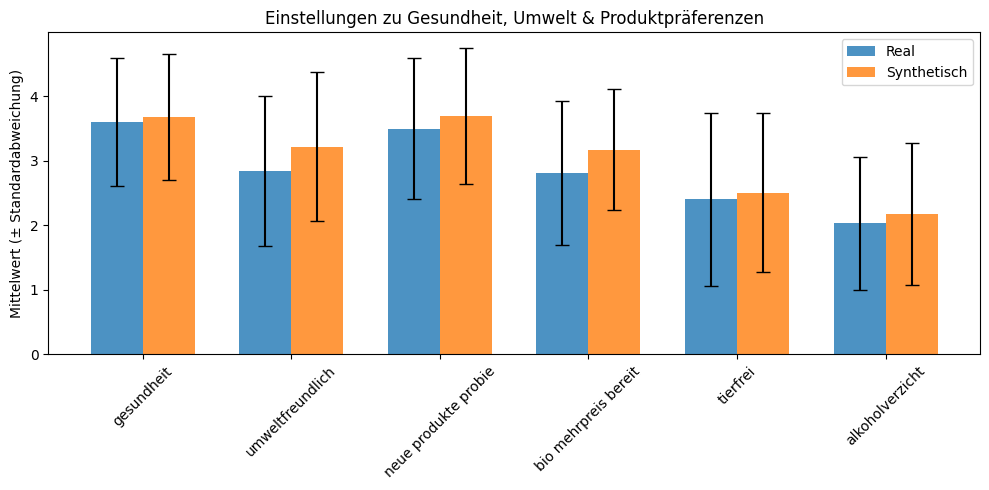

In [6]:
# Feature-Liste
bewertung_features = [
    "gesundheit_wichtig",
    "umweltfreundlich_wichtig",
    "neue_produkte_probie",
    "bio_mehrpreis_bereit",
    "tierfrei_wichtig",
    "alkoholverzicht_wichtig"
]

# Konvertiere zu numerisch (falls notwendig)
df_real[bewertung_features] = df_real[bewertung_features].apply(pd.to_numeric, errors='coerce')
df_syn[bewertung_features] = df_syn[bewertung_features].apply(pd.to_numeric, errors='coerce')

# Mittelwerte und Standardabweichungen berechnen
mean_real = df_real[bewertung_features].mean()
std_real = df_real[bewertung_features].std()
mean_syn = df_syn[bewertung_features].mean()
std_syn = df_syn[bewertung_features].std()

# Plot
x = range(len(bewertung_features))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetisch', alpha=0.8)

plt.xticks(x, [f.replace("_wichtig", "").replace("_", " ") for f in bewertung_features], rotation=45)
plt.ylabel("Mittelwert (± Standardabweichung)")
plt.title("Einstellungen zu Gesundheit, Umwelt & Produktpräferenzen")
plt.legend()
plt.tight_layout()
plt.show()


### Feature - Buying Decision

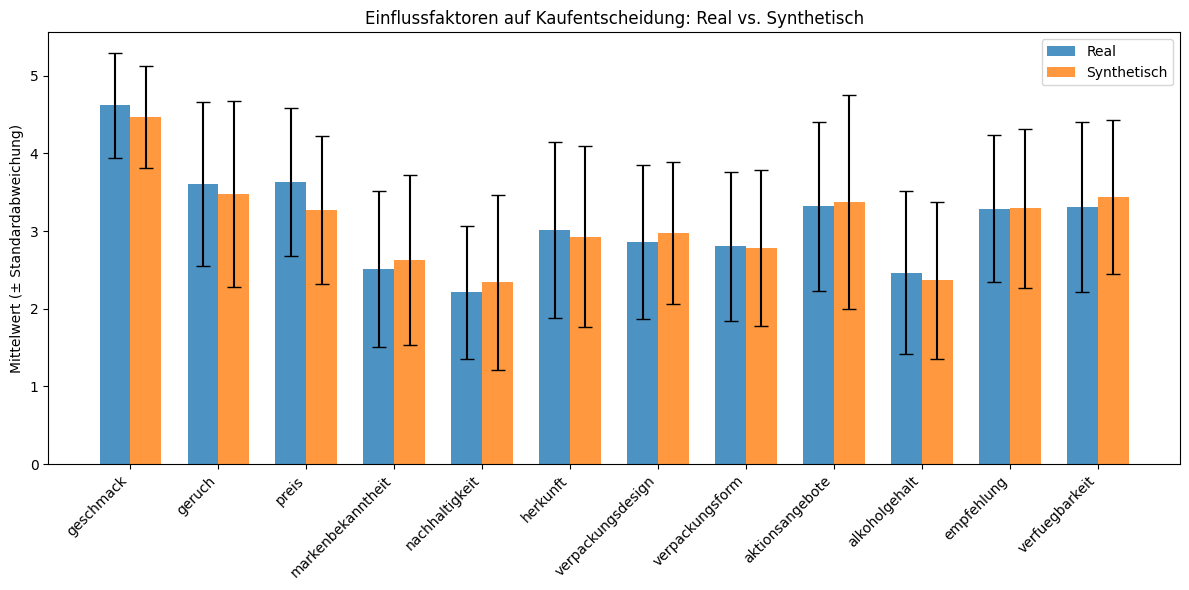

In [7]:
# Liste der Einfluss-Features
einfluss_features = [
    "einfluss_geschmack",
    "einfluss_geruch",
    "einfluss_preis",
    "einfluss_markenbekanntheit",
    "einfluss_nachhaltigkeit",
    "einfluss_herkunft",
    "einfluss_verpackungsdesign",
    "einfluss_verpackungsform",
    "einfluss_aktionsangebote",
    "einfluss_alkoholgehalt",
    "einfluss_empfehlung",
    "einfluss_verfuegbarkeit"
]

# Sicherstellen, dass alles numerisch ist
df_real[einfluss_features] = df_real[einfluss_features].apply(pd.to_numeric, errors='coerce')
df_syn[einfluss_features] = df_syn[einfluss_features].apply(pd.to_numeric, errors='coerce')

# Mittelwert & Standardabweichung
mean_real = df_real[einfluss_features].mean()
std_real = df_real[einfluss_features].std()
mean_syn = df_syn[einfluss_features].mean()
std_syn = df_syn[einfluss_features].std()

# Plot vorbereiten
x = range(len(einfluss_features))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=5, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=5, label='Synthetisch', alpha=0.8)

# Achsenbeschriftung lesbar formatieren
xtick_labels = [f.replace("einfluss_", "").replace("_", " ") for f in einfluss_features]
plt.xticks(x, xtick_labels, rotation=45, ha='right')

plt.ylabel("Mittelwert (± Standardabweichung)")
plt.title("Einflussfaktoren auf Kaufentscheidung: Real vs. Synthetisch")
plt.legend()
plt.tight_layout()
plt.show()


### Feature - Preferences

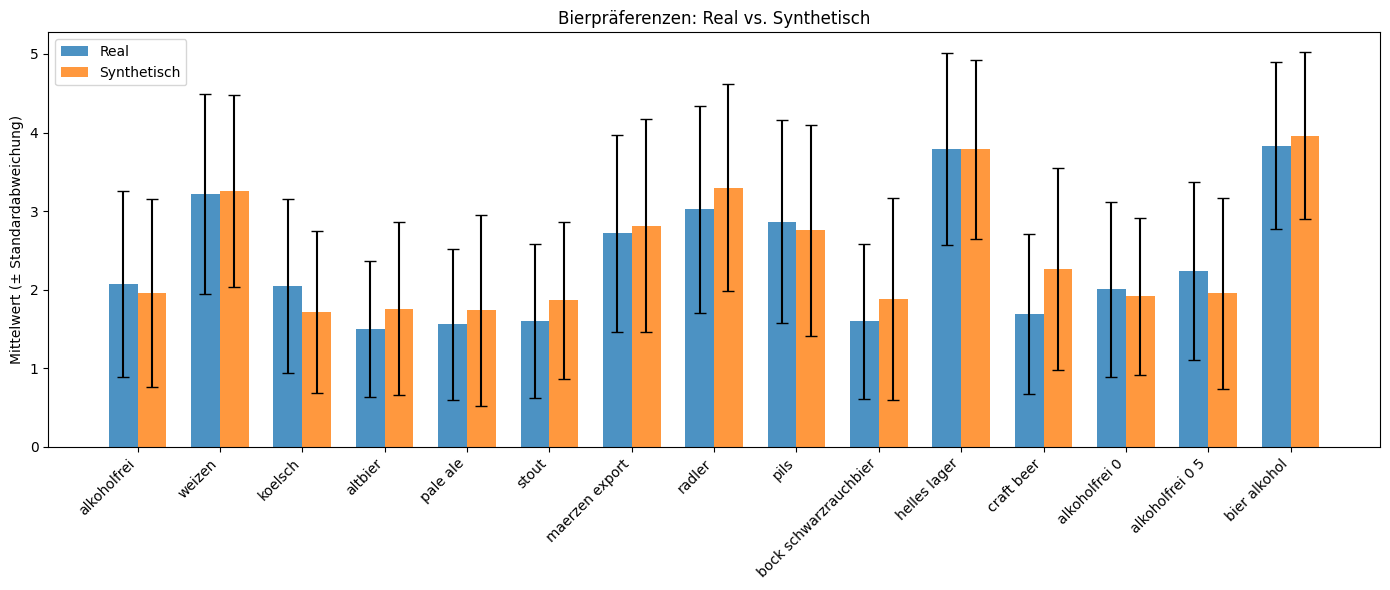

In [8]:
# Feature-Liste für Bierpräferenzen
bierpraef_features = [
    "praef_sorte_alkoholfrei",
    "praef_sorte_weizen",
    "praef_sorte_koelsch",
    "praef_sorte_altbier",
    "praef_sorte_pale_ale",
    "praef_sorte_stout",
    "praef_sorte_maerzen_export",
    "praef_sorte_radler",
    "praef_sorte_pils",
    "praef_sorte_bock_schwarzrauchbier",
    "praef_sorte_helles_lager",
    "praef_sorte_craft_beer",
    "praef_alkoholfrei_0",
    "praef_alkoholfrei_0_5",
    "praef_bier_alkohol"
]

# Sicherstellen, dass die Werte numerisch sind
df_real[bierpraef_features] = df_real[bierpraef_features].apply(pd.to_numeric, errors='coerce')
df_syn[bierpraef_features] = df_syn[bierpraef_features].apply(pd.to_numeric, errors='coerce')

# Mittelwerte und Standardabweichung berechnen
mean_real = df_real[bierpraef_features].mean()
std_real = df_real[bierpraef_features].std()
mean_syn = df_syn[bierpraef_features].mean()
std_syn = df_syn[bierpraef_features].std()

# Plot
x = range(len(bierpraef_features))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=4, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=4, label='Synthetisch', alpha=0.8)

# X-Achsenbeschriftungen formatieren
xtick_labels = [f.replace("praef_sorte_", "").replace("praef_", "").replace("_", " ") for f in bierpraef_features]
plt.xticks(x, xtick_labels, rotation=45, ha='right')

plt.ylabel("Mittelwert (± Standardabweichung)")
plt.title("Bierpräferenzen: Real vs. Synthetisch")
plt.legend()
plt.tight_layout()
plt.show()


### Feature - Taste Preferences

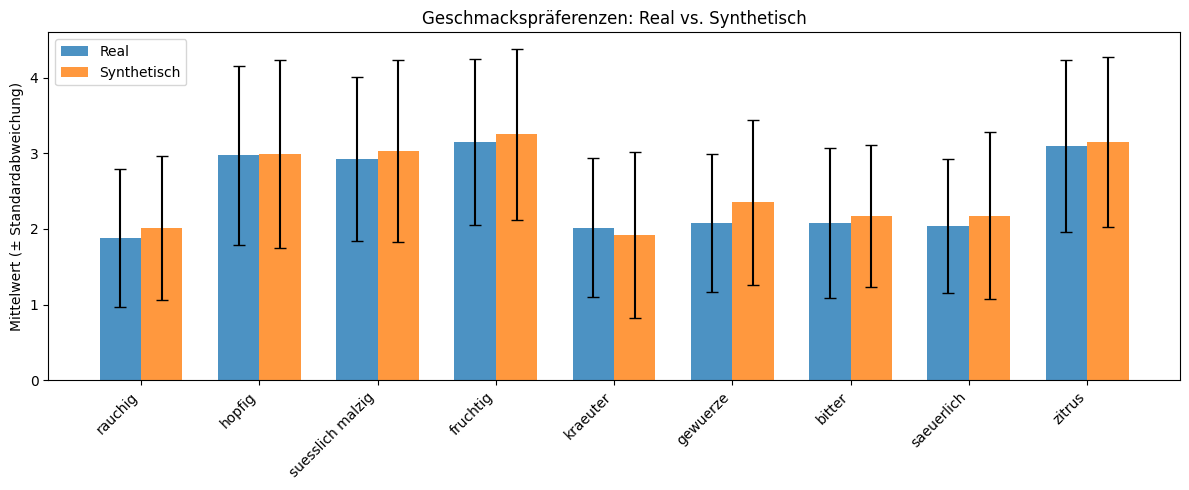

In [9]:
# Liste der Geschmacksmerkmale
geschmack_features = [
    "geschmack_rauchig",
    "geschmack_hopfig",
    "geschmack_suesslich_malzig",
    "geschmack_fruchtig",
    "geschmack_kraeuter",
    "geschmack_gewuerze",
    "geschmack_bitter",
    "geschmack_saeuerlich",
    "geschmack_zitrus"
]

# Numerisch sicherstellen
df_real[geschmack_features] = df_real[geschmack_features].apply(pd.to_numeric, errors='coerce')
df_syn[geschmack_features] = df_syn[geschmack_features].apply(pd.to_numeric, errors='coerce')

# Mittelwert & Standardabweichung berechnen
mean_real = df_real[geschmack_features].mean()
std_real = df_real[geschmack_features].std()
mean_syn = df_syn[geschmack_features].mean()
std_syn = df_syn[geschmack_features].std()

# Plot
x = range(len(geschmack_features))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar([i - width/2 for i in x], mean_real, width, yerr=std_real, capsize=4, label='Real', alpha=0.8)
plt.bar([i + width/2 for i in x], mean_syn, width, yerr=std_syn, capsize=4, label='Synthetisch', alpha=0.8)

# Achsenbeschriftungen bereinigen
xtick_labels = [f.replace("geschmack_", "").replace("_", " ") for f in geschmack_features]
plt.xticks(x, xtick_labels, rotation=45, ha='right')

plt.ylabel("Mittelwert (± Standardabweichung)")
plt.title("Geschmackspräferenzen: Real vs. Synthetisch")
plt.legend()
plt.tight_layout()
plt.show()


### Correlation Matrix

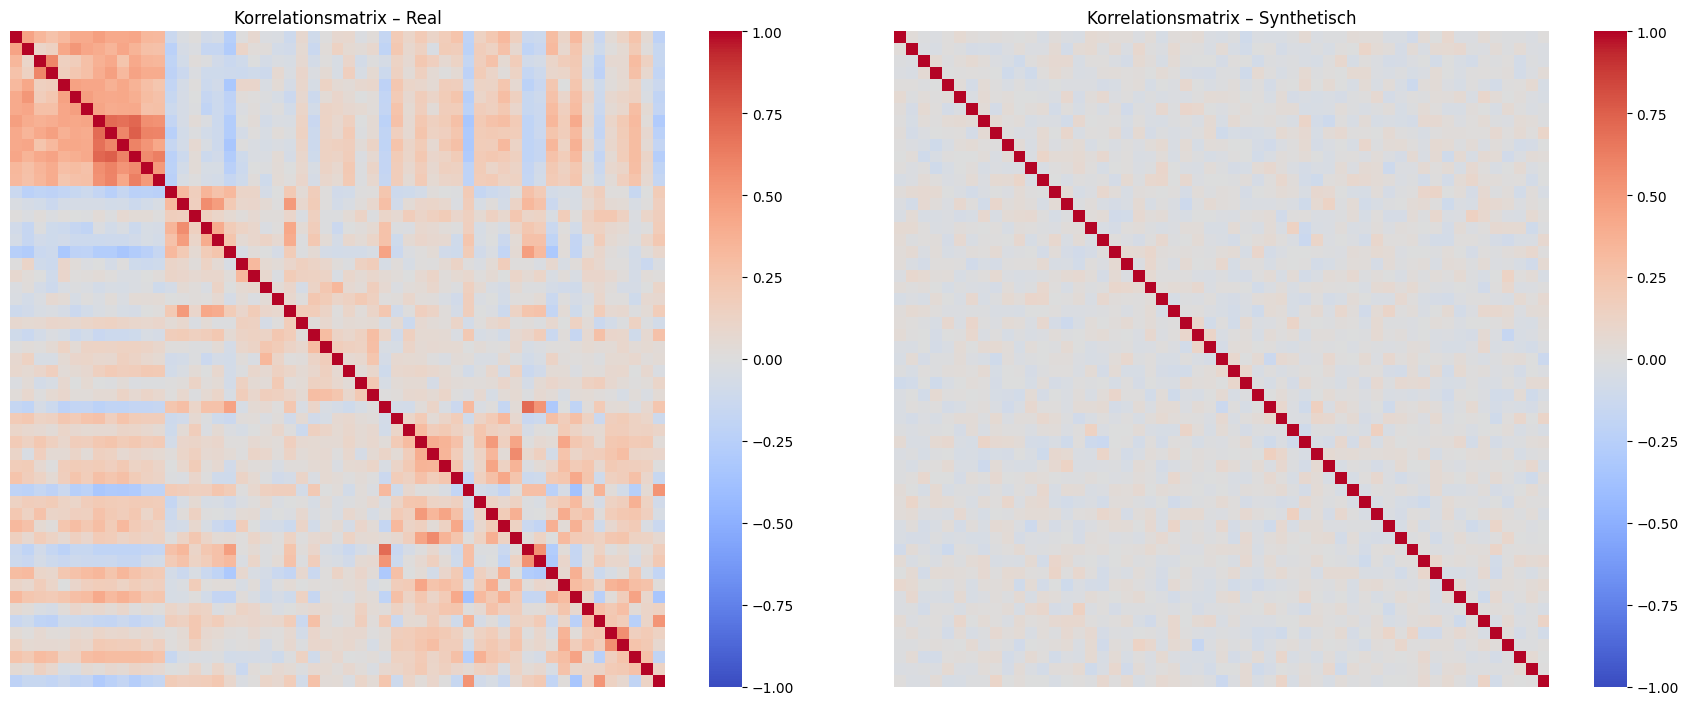

In [10]:
# Numerische Spalten automatisch auswählen
df_real_num = df_real.select_dtypes(include='number')
df_syn_num = df_syn.select_dtypes(include='number')

# Korrelationen berechnen
corr_real = df_real_num.corr()
corr_syn = df_syn_num.corr()

# Plot ohne Feature-Namen
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_real, ax=axes[0], cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar=True,
            xticklabels=False, yticklabels=False, square=True)
axes[0].set_title("Korrelationsmatrix – Real")

sns.heatmap(corr_syn, ax=axes[1], cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar=True,
            xticklabels=False, yticklabels=False, square=True)
axes[1].set_title("Korrelationsmatrix – Synthetisch")

plt.tight_layout()
plt.show()


# Structural Consistency

### PCA

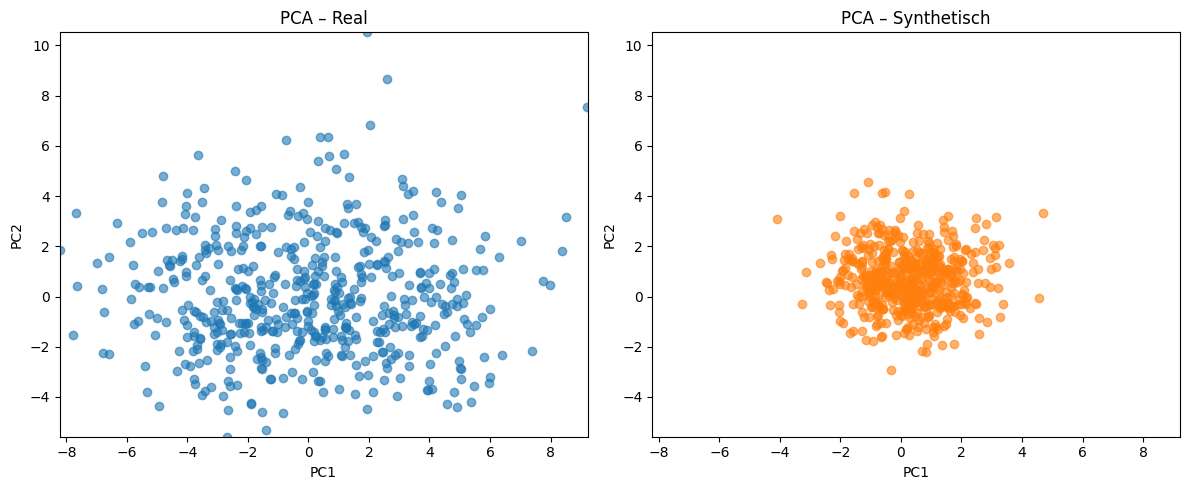

In [11]:
# Numerische Daten extrahieren und gemeinsame Spalten finden
df_real_num = df_real.select_dtypes(include='number').dropna(axis=1)
df_syn_num = df_syn.select_dtypes(include='number').dropna(axis=1)

common_cols = list(set(df_real_num.columns) & set(df_syn_num.columns))
df_real_num = df_real_num[common_cols]
df_syn_num = df_syn_num[common_cols]

# PCA: auf realen Daten fitten, beide transformieren
pca = PCA(n_components=2)
real_pca = pca.fit_transform(df_real_num)
syn_pca = pca.transform(df_syn_num)

# Visualisierung: nebeneinander
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.6, c='tab:blue')
axes[0].set_title("PCA – Real")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(syn_pca[:, 0], syn_pca[:, 1], alpha=0.6, c='tab:orange')
axes[1].set_title("PCA – Synthetisch")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# Gleiche Achsenskalierung für beide
x_min = min(real_pca[:, 0].min(), syn_pca[:, 0].min())
x_max = max(real_pca[:, 0].max(), syn_pca[:, 0].max())
y_min = min(real_pca[:, 1].min(), syn_pca[:, 1].min())
y_max = max(real_pca[:, 1].max(), syn_pca[:, 1].max())

for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


### t-SNE

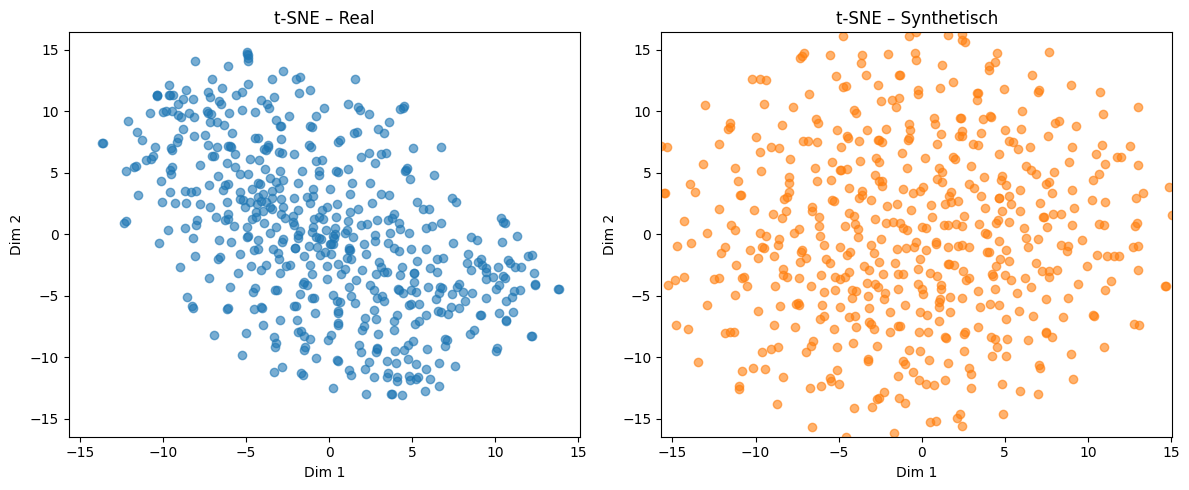

In [12]:

# t-SNE für reale und synthetische Daten
tsne_real = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
real_tsne = tsne_real.fit_transform(df_real_num)

tsne_syn = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
syn_tsne = tsne_syn.fit_transform(df_syn_num)

# Gemeinsame Achsengrenzen berechnen
x_min = min(real_tsne[:, 0].min(), syn_tsne[:, 0].min())
x_max = max(real_tsne[:, 0].max(), syn_tsne[:, 0].max())
y_min = min(real_tsne[:, 1].min(), syn_tsne[:, 1].min())
y_max = max(real_tsne[:, 1].max(), syn_tsne[:, 1].max())

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_tsne[:, 0], real_tsne[:, 1], alpha=0.6, c='tab:blue')
axes[0].set_title("t-SNE – Real")
axes[0].set_xlabel("Dim 1")
axes[0].set_ylabel("Dim 2")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

axes[1].scatter(syn_tsne[:, 0], syn_tsne[:, 1], alpha=0.6, c='tab:orange')
axes[1].set_title("t-SNE – Synthetisch")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


### Joint t-SNE

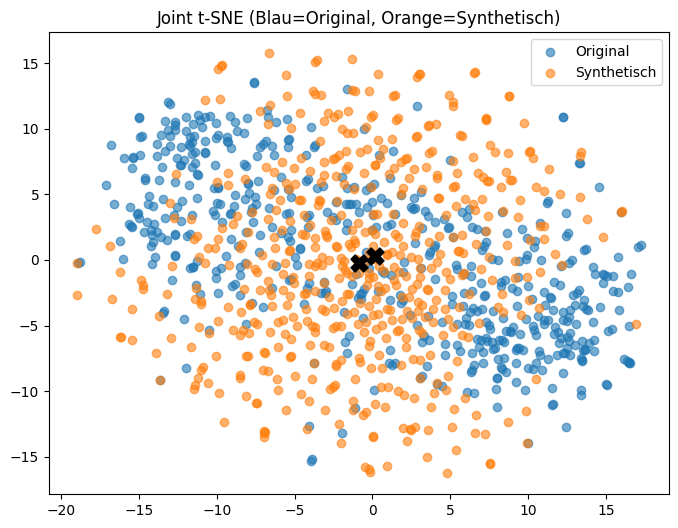

In [14]:
def centroide(original: pd.DataFrame,
              synthetic: pd.DataFrame,
              eps=0.5,
              min_samples=5):
    
    # numerische & kategoriale Spalten extrahieren
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)
    
    # Kategoriale Features One-Hot-Enkodieren
    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))
    
    # Numerische Features skalieren
    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler()
    scaler.fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)
    
    # Kombinieren
    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels_orig = np.zeros(len(X_orig), dtype=int)   # 0 = Original
    labels_syn  = np.ones(len(X_syn),  dtype=int)    # 1 = Synthetisch

    X_joint = np.vstack([X_orig, X_syn])
    labels = np.concatenate([labels_orig, labels_syn])

    # Farben: 0 -> Blau, 1 -> Orange
    color_map = {0: '#1f77b4', 1: '#ff7f0e'}

    # t-SNE
    tsne_joint = TSNE(n_components=2, random_state=42).fit_transform(X_joint)

    # Zentroiden pro Klasse (Original/Synthetisch)
    centroids = []
    for label in np.unique(labels):
        points = tsne_joint[labels == label]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
    centroids = np.array(centroids)

    # Plot
    plt.figure(figsize=(8, 6))
    for label in np.unique(labels):
        idx = labels == label
        plt.scatter(tsne_joint[idx, 0], tsne_joint[idx, 1],
                    c=color_map[label],
                    label="Original" if label == 0 else "Synthetisch",
                    alpha=0.6)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                c='black', marker='X', s=150)  # Zentroiden in Schwarz
    plt.title('Joint t-SNE (Blau=Original, Orange=Synthetisch)')
    plt.legend()
    plt.show()


centroide(df_real,df_syn)


### K-Means Clustering

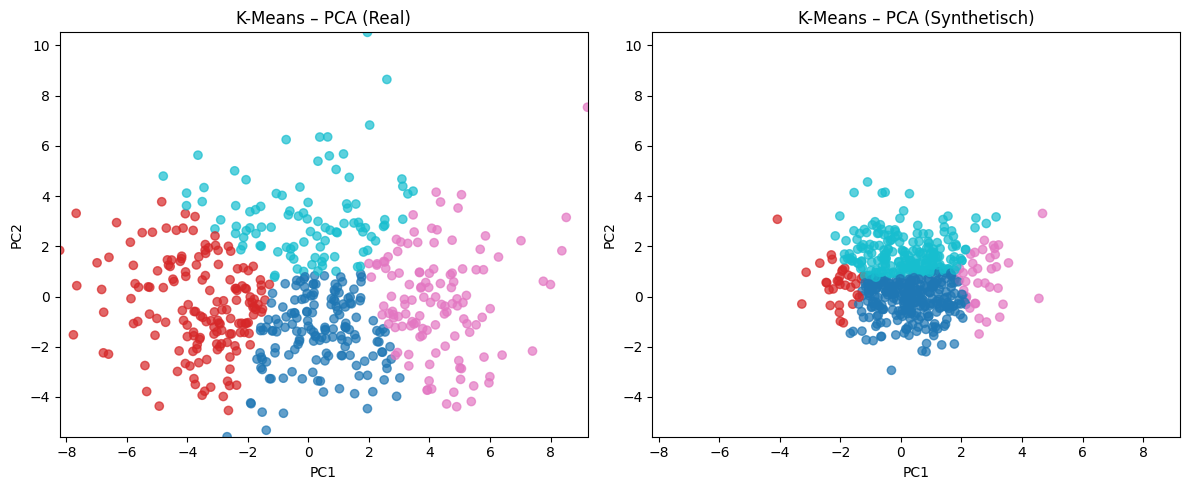

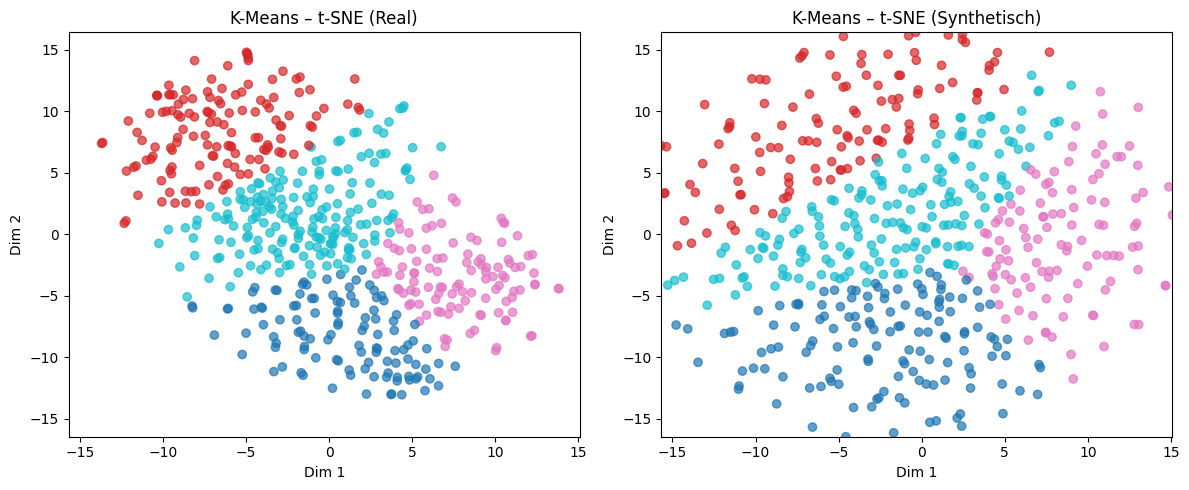

Silhouette Score (PCA – Real):         0.32547848707620664
Silhouette Score (PCA – Synthetisch):  0.24165569159375686
Silhouette Score (t-SNE – Real):       0.36166661977767944
Silhouette Score (t-SNE – Synthetisch): 0.2683827877044678


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Anzahl der Cluster
n_clusters = 4

# --- PCA-Clustering ---
kmeans_pca = KMeans(n_clusters=n_clusters, random_state=42)
clusters_real_pca = kmeans_pca.fit_predict(real_pca)
clusters_syn_pca = kmeans_pca.predict(syn_pca)

# Achsenskalen (PCA)
x_min_pca = min(real_pca[:, 0].min(), syn_pca[:, 0].min())
x_max_pca = max(real_pca[:, 0].max(), syn_pca[:, 0].max())
y_min_pca = min(real_pca[:, 1].min(), syn_pca[:, 1].min())
y_max_pca = max(real_pca[:, 1].max(), syn_pca[:, 1].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(real_pca[:, 0], real_pca[:, 1], c=clusters_real_pca, cmap='tab10', alpha=0.7)
axes[0].set_title("K-Means – PCA (Real)")
axes[0].set_xlim(x_min_pca, x_max_pca)
axes[0].set_ylim(y_min_pca, y_max_pca)

axes[1].scatter(syn_pca[:, 0], syn_pca[:, 1], c=clusters_syn_pca, cmap='tab10', alpha=0.7)
axes[1].set_title("K-Means – PCA (Synthetisch)")
axes[1].set_xlim(x_min_pca, x_max_pca)
axes[1].set_ylim(y_min_pca, y_max_pca)

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()


# --- t-SNE-Clustering ---
kmeans_tsne = KMeans(n_clusters=n_clusters, random_state=42)
clusters_real_tsne = kmeans_tsne.fit_predict(real_tsne)
clusters_syn_tsne = kmeans_tsne.predict(syn_tsne)

x_min_tsne = min(real_tsne[:, 0].min(), syn_tsne[:, 0].min())
x_max_tsne = max(real_tsne[:, 0].max(), syn_tsne[:, 0].max())
y_min_tsne = min(real_tsne[:, 1].min(), syn_tsne[:, 1].min())
y_max_tsne = max(real_tsne[:, 1].max(), syn_tsne[:, 1].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(real_tsne[:, 0], real_tsne[:, 1], c=clusters_real_tsne, cmap='tab10', alpha=0.7)
axes[0].set_title("K-Means – t-SNE (Real)")
axes[0].set_xlim(x_min_tsne, x_max_tsne)
axes[0].set_ylim(y_min_tsne, y_max_tsne)

axes[1].scatter(syn_tsne[:, 0], syn_tsne[:, 1], c=clusters_syn_tsne, cmap='tab10', alpha=0.7)
axes[1].set_title("K-Means – t-SNE (Synthetisch)")
axes[1].set_xlim(x_min_tsne, x_max_tsne)
axes[1].set_ylim(y_min_tsne, y_max_tsne)

for ax in axes:
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()



# --- Optional: Clustering-Qualität bewerten (Silhouette) ---
print("Silhouette Score (PCA – Real):        ", silhouette_score(real_pca, clusters_real_pca))
print("Silhouette Score (PCA – Synthetisch): ", silhouette_score(syn_pca, clusters_syn_pca))
print("Silhouette Score (t-SNE – Real):      ", silhouette_score(real_tsne, clusters_real_tsne))
print("Silhouette Score (t-SNE – Synthetisch):", silhouette_score(syn_tsne, clusters_syn_tsne))


### Agglomerative Clustering

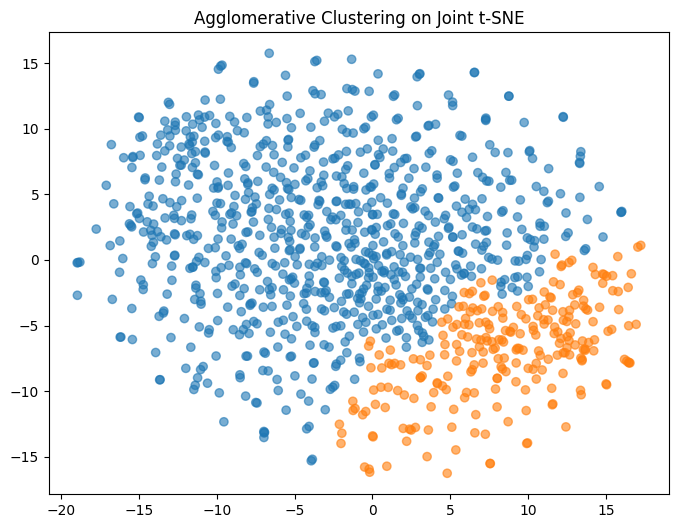

In [16]:




def visualize_structural_consistency(original: pd.DataFrame,
                                     synthetic: pd.DataFrame,
                                     eps=0.5,
                                     min_samples=5):
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)

    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))

    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler()
    scaler.fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)

    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels_orig = np.zeros(len(X_orig), dtype=int)
    labels_syn  = np.ones(len(X_syn),  dtype=int)

    X_joint = np.vstack([X_orig, X_syn])
    labels = np.concatenate([labels_orig, labels_syn])

    color_map = {0: '#1f77b4', 1: '#ff7f0e'}

    # t-SNE
    tsne_joint = TSNE(n_components=2, random_state=42).fit_transform(X_joint)

    # Clustering
    agg_cluster = AgglomerativeClustering(n_clusters=2).fit(tsne_joint)
    cluster_labels = agg_cluster.labels_

    # Zentroiden berechnen
    centroids = []
    for label in np.unique(cluster_labels):
        points = tsne_joint[cluster_labels == label]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
    centroids = np.array(centroids)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(tsne_joint[:, 0], tsne_joint[:, 1],
                c=[color_map[label] if label in color_map else 'gray' for label in cluster_labels],
                alpha=0.6)
    plt.title("Agglomerative Clustering on Joint t-SNE")
    plt.show()

visualize_structural_consistency(df_real, df_syn)